In [26]:
import pandas as pd

In [27]:
# 读取Excel文件
df_entrances = pd.read_excel('output/3s6e_entrance_info.xlsx')
df_stations = pd.read_excel('output/3s6e_station_demand_info.xlsx')

print(df_entrances)
print(df_stations)

# 提取出入口和站点信息
entrances = df_entrances[['node_idx', 'distance']]
stations = df_stations[['node_idx', 'distance']]

print(entrances)
print(stations)


# 定义一个函数来找到两个出入口之间经过的站点，并按方向排序
def find_stations_between(start, end):
    start_distance = entrances.loc[entrances['node_idx'] == start, 'distance'].values[0]
    end_distance = entrances.loc[entrances['node_idx'] == end, 'distance'].values[0]
    
    if start_distance < end_distance:
        passing_stations = stations[(stations['distance'] >= start_distance) & (stations['distance'] <= end_distance)]
    else:
        passing_stations = stations[(stations['distance'] <= start_distance) & (stations['distance'] >= end_distance)].sort_values(by='distance', ascending=False)
    
    return passing_stations['node_idx'].tolist(), abs(end_distance - start_distance)

# 双向的O-D对
# 生成子路径列表
subpaths = []
path_id = 1
minL=200  # 只挑选路径长度大于等于200的O-D对

print(find_stations_between('e1', 'e5'))

for i, start in entrances.iterrows():
    for j, end in entrances.iterrows():
        if start['node_idx'] != end['node_idx']: # 确保不生成同一出入口的路径
            stations_between, path_length = find_stations_between(start['node_idx'], end['node_idx'])
            if path_length >= minL and stations_between: # 只保留路径长度大于等于200且有经过站点的路径
                subpaths.append([f'p{path_id}', start['node_idx'], end['node_idx'], ','.join(stations_between)])
                path_id += 1

# 转换为DataFrame并保存为CSV
subpaths_df = pd.DataFrame(subpaths, columns=['PATH', 'SOURCE', 'ROOT', 'STATIONS'])
subpaths_df.to_csv('subpaths_6e.csv', index=False)
print(subpaths_df)



  node_idx          node_name        Lat         Lng  distance
0       e1      G2京沪高速入口(西北向)  39.857496  116.461564         0
1       e2    保津高速公路有限公司冀津收费站  39.152470  116.855860        94
2       e3     西花园收费站入口(北京方向)  38.402720  116.848200       177
3       e4    乐陵南出口(G2京沪高速南向)  37.523021  117.118729       279
4       e5     济阳出口(G2京沪高速南向)  36.973630  117.058010       340
5       e6  莱芜高新区出口(G2京沪高速东向)  36.258120  117.720880       440
  node_idx                node_name       Lat        Lng  distance  \
0       s1            蔚来换电站(泗村店服务区)  39.44629  116.93159        61   
1       s2  蔚来换电站(G2京沪高速乐陵西服务区北京方向)  37.73651  117.11062       255   
2       s3          蔚来换电站(济南唐冶春江悦茗)  36.68668  117.21932       375   

                                                 1  \
0  0,0,0,0,0,0,0,1,1,1,2,2,2,2,4,4,4,5,3,3,2,1,1,1   
1  1,0,0,0,0,0,0,0,1,1,2,2,3,3,5,4,3,1,2,1,2,1,0,1   
2  0,0,0,0,0,0,0,0,1,1,3,2,5,6,3,3,3,2,2,1,2,1,1,0   

                                                 2  \
0  1,1,

In [28]:
# 读取CSV文件的第一个sheet
df = pd.read_csv('output/subpaths_6e.csv')

# 创建一个空字典来存储路径信息和对应的弧
paths = {}

# 将路径信息存储到字典中
for index, row in df.iterrows():
    path_name = row['PATH']
    source = row['SOURCE']
    root = row['ROOT']
    station_list = row['STATIONS'].split(',')
    
    # 生成路径中的弧
    arcs = [(source, station_list[0])]
    for i in range(len(station_list) - 1):
        arcs.append((station_list[i], station_list[i+1]))
    arcs.append((station_list[-1], root))
    
    paths[path_name] = {'source': source, 'root': root, 'stations': station_list, 'arcs': arcs}

paths

{'p1': {'source': 'e1',
  'root': 'e4',
  'stations': ['s1', 's2'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 'e4')]},
 'p2': {'source': 'e1',
  'root': 'e5',
  'stations': ['s1', 's2'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 'e5')]},
 'p3': {'source': 'e1',
  'root': 'e6',
  'stations': ['s1', 's2', 's3'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 'e6')]},
 'p4': {'source': 'e2',
  'root': 'e5',
  'stations': ['s2'],
  'arcs': [('e2', 's2'), ('s2', 'e5')]},
 'p5': {'source': 'e2',
  'root': 'e6',
  'stations': ['s2', 's3'],
  'arcs': [('e2', 's2'), ('s2', 's3'), ('s3', 'e6')]},
 'p6': {'source': 'e3',
  'root': 'e6',
  'stations': ['s2', 's3'],
  'arcs': [('e3', 's2'), ('s2', 's3'), ('s3', 'e6')]},
 'p7': {'source': 'e4',
  'root': 'e1',
  'stations': ['s2', 's1'],
  'arcs': [('e4', 's2'), ('s2', 's1'), ('s1', 'e1')]},
 'p8': {'source': 'e5',
  'root': 'e1',
  'stations': ['s2', 's1'],
  'arcs': [('e5', 's2'), ('s2', 's1'), ('s1', 'e1')]},
 'p9': {'source'

In [29]:
# 打印存储的路径信息和对应的弧
for path_name, path_info in paths.items():
    print(f"Path: {path_name}")
    print("Source:", path_info['source'])
    print("Root:", path_info['root'])
    print("Stations:", path_info['stations'])
    print("Arcs:", path_info['arcs'])
    print()

Path: p1
Source: e1
Root: e4
Stations: ['s1', 's2']
Arcs: [('e1', 's1'), ('s1', 's2'), ('s2', 'e4')]

Path: p2
Source: e1
Root: e5
Stations: ['s1', 's2']
Arcs: [('e1', 's1'), ('s1', 's2'), ('s2', 'e5')]

Path: p3
Source: e1
Root: e6
Stations: ['s1', 's2', 's3']
Arcs: [('e1', 's1'), ('s1', 's2'), ('s2', 's3'), ('s3', 'e6')]

Path: p4
Source: e2
Root: e5
Stations: ['s2']
Arcs: [('e2', 's2'), ('s2', 'e5')]

Path: p5
Source: e2
Root: e6
Stations: ['s2', 's3']
Arcs: [('e2', 's2'), ('s2', 's3'), ('s3', 'e6')]

Path: p6
Source: e3
Root: e6
Stations: ['s2', 's3']
Arcs: [('e3', 's2'), ('s2', 's3'), ('s3', 'e6')]

Path: p7
Source: e4
Root: e1
Stations: ['s2', 's1']
Arcs: [('e4', 's2'), ('s2', 's1'), ('s1', 'e1')]

Path: p8
Source: e5
Root: e1
Stations: ['s2', 's1']
Arcs: [('e5', 's2'), ('s2', 's1'), ('s1', 'e1')]

Path: p9
Source: e5
Root: e2
Stations: ['s2']
Arcs: [('e5', 's2'), ('s2', 'e2')]

Path: p10
Source: e6
Root: e1
Stations: ['s3', 's2', 's1']
Arcs: [('e6', 's3'), ('s3', 's2'), ('s2', '

In [30]:
# 计算距离矩阵并保存到 output/dist_6e.csv
import os
import numpy as np

# 合并站点和出入口，去重（按 node_idx）
df_all = pd.concat([stations, entrances], ignore_index=True).drop_duplicates(subset='node_idx').reset_index(drop=True)

# 使用 node_idx 作为索引（用于行列标签）
node_idxs = df_all['node_idx'].tolist()
distances = df_all['distance'].values

# 计算成对绝对距离矩阵（沿路段的距离差的绝对值）
distance_matrix = np.abs(distances.reshape(-1, 1) - distances.reshape(1, -1))

# 转换为 DataFrame，行列索引为 node_idx
matrix_df = pd.DataFrame(distance_matrix, index=node_idxs, columns=node_idxs)

# 确保 output 目录存在并保存
os.makedirs('output', exist_ok=True)
output_path = os.path.join('output', 'dist_6e.csv')
matrix_df.to_csv(output_path)
print(f"距离矩阵已保存: {output_path}")

距离矩阵已保存: output\dist_6e.csv


In [31]:
import pandas as pd
dist = pd.read_csv('output/dist_6e.csv',header=0,index_col=0)
dist


,s1,s2,s3,e1,e2,e3,e4,e5,e6
s1,0,194,314,61,33,116,218,279,379
s2,194,0,120,255,161,78,24,85,185
s3,314,120,0,375,281,198,96,35,65
e1,61,255,375,0,94,177,279,340,440
e2,33,161,281,94,0,83,185,246,346
e3,116,78,198,177,83,0,102,163,263
e4,218,24,96,279,185,102,0,61,161
e5,279,85,35,340,246,163,61,0,100
e6,379,185,65,440,346,263,161,100,0


In [33]:
RangeL = 400 # 长续航电池里程
N = {0: 0, 1: 80, 2: 160, 3: 240, 4: 320, 5: 400} # 离散电池soc水平数量           

for path_name, path_info in paths.items():
    path_info['strategy'] = {} # 初始化从1-N的key,value为[]
    path_info['A'] = {}
    path_info['PATH'] = {}
    
    for soc_level in range(2, len(N)): # 从2开始，因为假设初始电池SOC水平>=2
        path_info['A'][soc_level] = path_info['arcs'].copy() # 初始化A为原始弧列表
        path_info['strategy'][soc_level] = [] # 初始化策略为空列表
        path_info['PATH'][soc_level] = []
        for station in path_info['stations']:

            # Step1 Add Arc from source node
            # 这里的条件是如果source节点和station之间的距离小于等于初始电量距离，并且这个弧不在A中，就添加这个弧到A中
            if dist[path_info['source']][station] <= N[soc_level] and (path_info['source'], station) not in path_info['A'][soc_level]:
                path_info['A'][soc_level].append((path_info['source'], station))

            # Step2 Add Arc to root node
            # 这里的条件是如果station节点和root节点之间的距离小于等于RangeL/2，并且这个弧不在A中，就添加这个弧到A中
            if dist[station][path_info['root']] <= RangeL / 2 and (station, path_info['root']) not in path_info['A'][soc_level]:
                path_info['A'][soc_level].append((station, path_info['root']))

        # Step3 Add Arc between stations and record path
        # 注意为什么是+2，因为+1已经在初始化AS和AL的时候添加了相邻站点之间的弧了，所以这里要跳过相邻站点之间的弧
        for idx in range(len(path_info['stations']) - 2):
            for j in range(idx + 2, len(path_info['stations'])):
                station1 = path_info['stations'][idx]
                station2 = path_info['stations'][j]

                if dist[station1][station2] <= RangeL:
                    path_info['A'][soc_level].append((station1, station2))
                else:
                    break

paths


{'p1': {'source': 'e1',
  'root': 'e4',
  'stations': ['s1', 's2'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 'e4')],
  'strategy': {2: [], 3: [], 4: [], 5: []},
  'A': {2: [('e1', 's1'), ('s1', 's2'), ('s2', 'e4')],
   3: [('e1', 's1'), ('s1', 's2'), ('s2', 'e4')],
   4: [('e1', 's1'), ('s1', 's2'), ('s2', 'e4'), ('e1', 's2')],
   5: [('e1', 's1'), ('s1', 's2'), ('s2', 'e4'), ('e1', 's2')]},
  'PATH': {2: [], 3: [], 4: [], 5: []}},
 'p2': {'source': 'e1',
  'root': 'e5',
  'stations': ['s1', 's2'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 'e5')],
  'strategy': {2: [], 3: [], 4: [], 5: []},
  'A': {2: [('e1', 's1'), ('s1', 's2'), ('s2', 'e5')],
   3: [('e1', 's1'), ('s1', 's2'), ('s2', 'e5')],
   4: [('e1', 's1'), ('s1', 's2'), ('s2', 'e5'), ('e1', 's2')],
   5: [('e1', 's1'), ('s1', 's2'), ('s2', 'e5'), ('e1', 's2')]},
  'PATH': {2: [], 3: [], 4: [], 5: []}},
 'p3': {'source': 'e1',
  'root': 'e6',
  'stations': ['s1', 's2', 's3'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2'

In [35]:
# minDistS=200 #设置两个站点之间的距离阈值
minDistL=200 #设置两个站点之间的距离阈值

def dfs(graph, current, end, path, paths):
    '''深度优先搜索，找到从current到end的所有路径'''
    path.append(current)
    if current == end:
        paths.append(path.copy())
    else:
        for neighbor in graph.get(current, []):
            if neighbor not in path:
                dfs(graph, neighbor, end, path, paths)
    path.pop() # 恢复现场，以便继续搜索其他路径

def nodes_to_arcs(nodes):
    '''将路径中的节点列表转换为弧列表'''
    arcs = []
    for i in range(len(nodes) - 1):
        arcs.append((nodes[i], nodes[i+1]))
    return arcs

def cut_arcs(arcs, source, root, stations, min_dist):

    # 构建图形表示
    # 这里的图是一个邻接表，key是节点，value是一个列表，包含所有从这个节点出发的弧的终点
    # 并且图是针对于每一个O-D对的和每一个初始soc水平的A来构建的，所以每个A都会有一个对应的图

    graph = {}
    for arc in arcs:
        if arc[0] not in graph:
            graph[arc[0]] = []
        graph[arc[0]].append(arc[1])
    # print(graph)

    # 找到从起点到终点的所有路径
    all_paths = []
    dfs(graph, source, root, [], all_paths)
    # 没有返回值，但all_paths会被修改，包含所有从source到root的路径，每条路径是一个节点列表
    # print("所有路径（节点列表）:", all_paths)

    all_paths_arcs = [nodes_to_arcs(path) for path in all_paths]

    # 筛选距离小于 min_dist 且仅连接起点、站点的弧
    # 起点和站点集合
    entrances_and_stations = set([source] + stations)
    filtered_arcs = [
        arc for arc in arcs
        if dist[arc[0]][arc[1]] < min_dist
        and arc[0] in entrances_and_stations
        and arc[1] in entrances_and_stations
    ]

    # 根据弧的距离排序
    sorted_arcs = sorted(filtered_arcs, key=lambda x: dist[x[0]][x[1]])

    # 检查每个距离小于 min_dist 的弧是否在所有路径中都有，如果存在有路径没有这条弧，则从所有路径中移除包含该弧的路径
    for arc in sorted_arcs:
        arc_found_in_all_paths = all(arc in path for path in all_paths_arcs) # 检查弧是否在所有路径中都有
        if not arc_found_in_all_paths: # 如果不在所有路径中（还有其他路径可以包含起点和终点）
            all_paths_arcs = [path for path in all_paths_arcs if arc not in path] # 从所有路径中移除包含该弧的路径

    # 获取所有路径中的弧
    all_arcs = []
    for path in all_paths_arcs:
        all_arcs.extend(path)

    # 将弧列表转换为集合，再取并集
    merged_arcs = list(set(all_arcs))

    return merged_arcs, all_paths_arcs


for path_name, path_info in paths.items():
    for soc_level in range(2, len(N)):
        path_info['strategy'][soc_level], path_info['PATH'][soc_level] = cut_arcs(
            path_info['A'][soc_level],
            path_info['source'],
            path_info['root'],
            path_info['stations'],
            minDistL
        )
    # strategy是经过剪枝后的A，PATH是经过剪枝后的A对应的路径列表，每条路径是一个弧列表
paths


{'p1': {'source': 'e1',
  'root': 'e4',
  'stations': ['s1', 's2'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 'e4')],
  'strategy': {2: [('s2', 'e4'), ('e1', 's1'), ('s1', 's2')],
   3: [('s2', 'e4'), ('e1', 's1'), ('s1', 's2')],
   4: [('s2', 'e4'), ('e1', 's2')],
   5: [('s2', 'e4'), ('e1', 's2')]},
  'A': {2: [('e1', 's1'), ('s1', 's2'), ('s2', 'e4')],
   3: [('e1', 's1'), ('s1', 's2'), ('s2', 'e4')],
   4: [('e1', 's1'), ('s1', 's2'), ('s2', 'e4'), ('e1', 's2')],
   5: [('e1', 's1'), ('s1', 's2'), ('s2', 'e4'), ('e1', 's2')]},
  'PATH': {2: [[('e1', 's1'), ('s1', 's2'), ('s2', 'e4')]],
   3: [[('e1', 's1'), ('s1', 's2'), ('s2', 'e4')]],
   4: [[('e1', 's2'), ('s2', 'e4')]],
   5: [[('e1', 's2'), ('s2', 'e4')]]}},
 'p2': {'source': 'e1',
  'root': 'e5',
  'stations': ['s1', 's2'],
  'arcs': [('e1', 's1'), ('s1', 's2'), ('s2', 'e5')],
  'strategy': {2: [('s2', 'e5'), ('e1', 's1'), ('s1', 's2')],
   3: [('s2', 'e5'), ('e1', 's1'), ('s1', 's2')],
   4: [('s2', 'e5'), ('e1', 's2')],

In [36]:
import json
# 保存到文件
with open('data_6e.json', 'w') as f:
    json.dump(paths, f, ensure_ascii=False, indent=4)

In [38]:
# 从文件读取
with open('data_6e.json', 'r') as f:
    loaded_data = json.load(f)

print(loaded_data)

{'p1': {'source': 'e1', 'root': 'e4', 'stations': ['s1', 's2'], 'arcs': [['e1', 's1'], ['s1', 's2'], ['s2', 'e4']], 'strategy': {'2': [['s2', 'e4'], ['e1', 's1'], ['s1', 's2']], '3': [['s2', 'e4'], ['e1', 's1'], ['s1', 's2']], '4': [['s2', 'e4'], ['e1', 's2']], '5': [['s2', 'e4'], ['e1', 's2']]}, 'A': {'2': [['e1', 's1'], ['s1', 's2'], ['s2', 'e4']], '3': [['e1', 's1'], ['s1', 's2'], ['s2', 'e4']], '4': [['e1', 's1'], ['s1', 's2'], ['s2', 'e4'], ['e1', 's2']], '5': [['e1', 's1'], ['s1', 's2'], ['s2', 'e4'], ['e1', 's2']]}, 'PATH': {'2': [[['e1', 's1'], ['s1', 's2'], ['s2', 'e4']]], '3': [[['e1', 's1'], ['s1', 's2'], ['s2', 'e4']]], '4': [[['e1', 's2'], ['s2', 'e4']]], '5': [[['e1', 's2'], ['s2', 'e4']]]}}, 'p2': {'source': 'e1', 'root': 'e5', 'stations': ['s1', 's2'], 'arcs': [['e1', 's1'], ['s1', 's2'], ['s2', 'e5']], 'strategy': {'2': [['s2', 'e5'], ['e1', 's1'], ['s1', 's2']], '3': [['s2', 'e5'], ['e1', 's1'], ['s1', 's2']], '4': [['s2', 'e5'], ['e1', 's2']], '5': [['s2', 'e5'], ['e

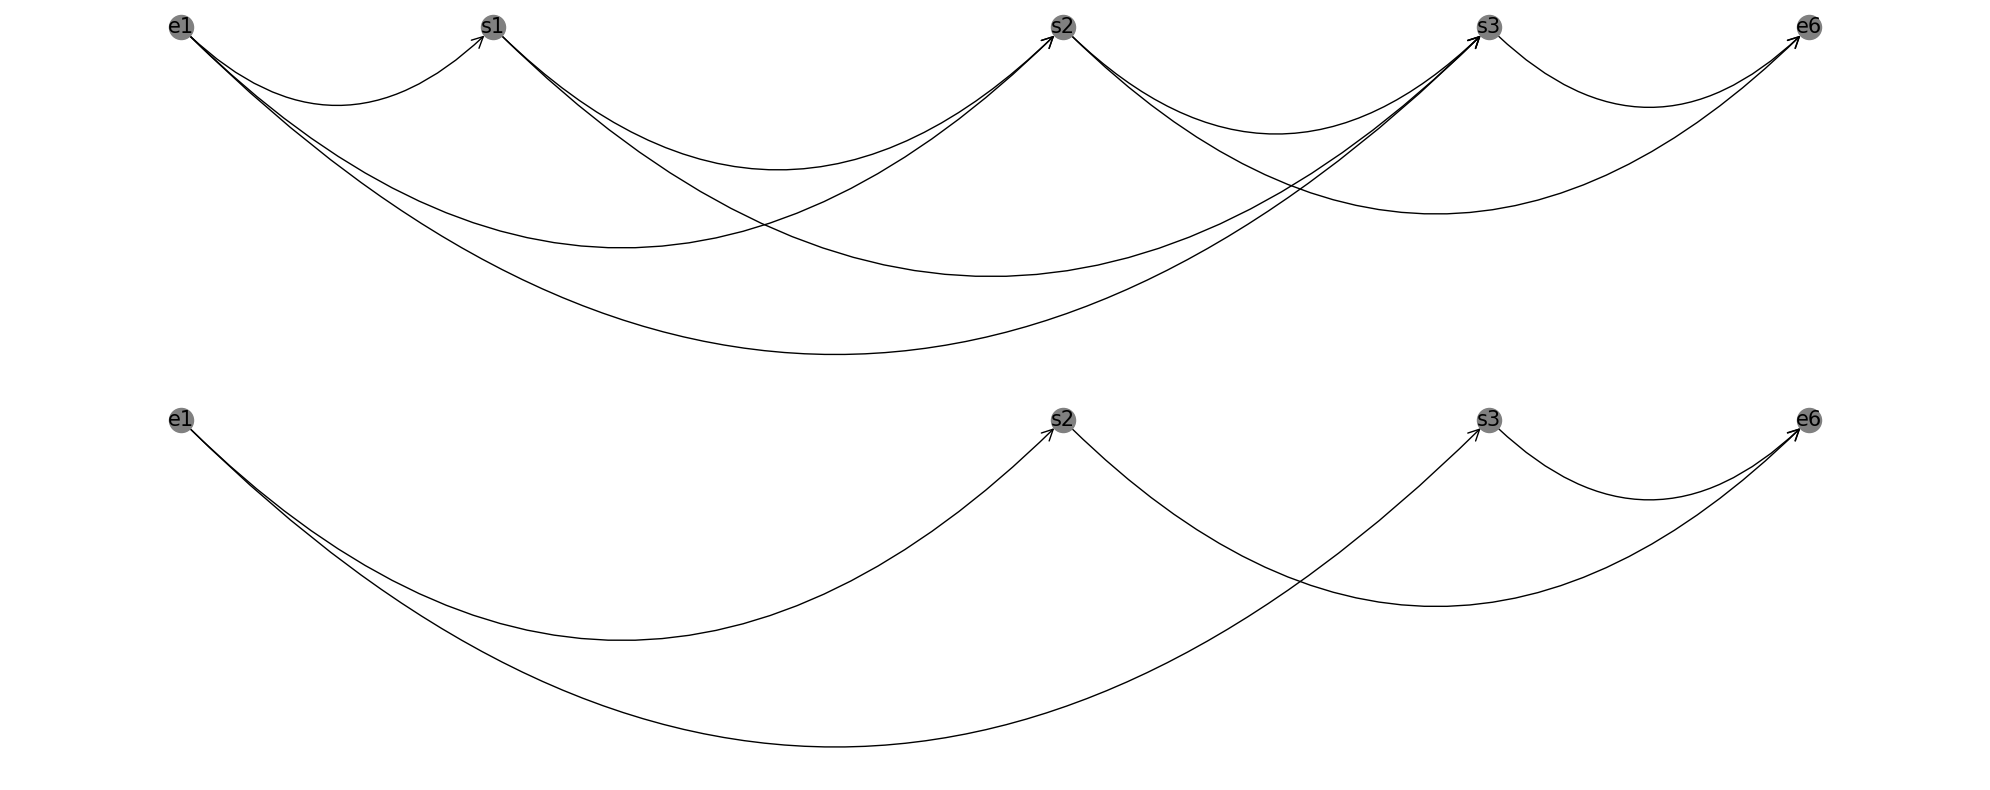

In [46]:
import matplotlib.pyplot as plt
import networkx as nx

# 计算每个节点的位置
def calculate_positions(source, stations, dist):
    positions = {source: 0}
    current_position = 0
    current_station = source

    for station in stations:
        if station in dist.columns and current_station in dist.index:
            current_position += dist[current_station][station]+100
            positions[station] = current_position
            current_station = station

    # 将所有位置转换为 (x, y) 格式，y 设为 0
    positions = {k: (v, 0) for k, v in positions.items()}
    return positions

def draw_network(path_info, Arcs, Strategy, dist):
    G_AS = nx.DiGraph()
    G_strategyS = nx.DiGraph()
    
    source = path_info['source']
    root = path_info['root']
    stations = path_info['stations'] + [root]
    
    # 计算节点位置
    pos = calculate_positions(source, stations, dist)
    
    # 添加AS网络中的弧
    for arc in Arcs:
        G_AS.add_edge(arc[0], arc[1])

    # 添加strategyS网络中的弧
    for arc in Strategy:
        G_strategyS.add_edge(arc[0], arc[1])

    # 创建图形并设置子图布局
    fig, axs = plt.subplots(2, 1, figsize=(20, 8))

    # 绘制第一个子图
    nx.draw(G_AS, pos, ax=axs[0],
            arrowstyle='->', 
            arrowsize=20, 
            width=1,
            with_labels=False, 
            node_size=300, 
            node_color='grey',
            edge_color='black',
            connectionstyle='arc3,rad=0.5')
    nx.draw_networkx_labels(G_AS, pos, ax=axs[0], font_size=15, font_color='black', verticalalignment='center')  # 调整标签的大小和位置


    # 绘制第二个子图
    nx.draw(G_strategyS, pos, ax=axs[1],
            arrowstyle='->', 
            arrowsize=20, 
            width=1,
            with_labels=False, 
            node_size=300, 
            node_color='grey',
            edge_color='black',
            connectionstyle='arc3,rad=0.5')
    nx.draw_networkx_labels(G_strategyS, pos, ax=axs[1], font_size=15, font_color='black', verticalalignment='center')  # 调整标签的大小和位置


    plt.tight_layout()  # 调整子图布局

    plt.show()

draw_network(paths['p3'], paths['p3']['A'][5], paths['p3']['strategy'][5], dist)